In [4]:
!pip install praw spacy bertopic sentence-transformers umap-learn hdbscan nltk gensim
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 91.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [31]:
import praw
import pandas as pd

# IMPORTANT: Replace "YOUR_CLIENT_ID" and "YOUR_CLIENT_SECRET" with your actual Reddit API credentials.
# You can obtain these by creating an application on Reddit's developer platform.
# For more information, visit: https://www.reddit.com/prefs/apps
reddit = praw.Reddit(
    client_id="YetFLz20wt1E6AmxeKZp9A",
    client_secret="W89zVKqYqr1LHfFe4pYfR9_zggowHQ",
    user_agent="mental_health_research:v1.0",
    check_for_async=False
)

reddit.read_only = True

subreddits = ["adhd", "adhdwomen", "mentalhealth", "malementalhealth"]

posts = []

for sub in subreddits:
    subreddit = reddit.subreddit(sub)
    for submission in subreddit.top(time_filter="year", limit=1000):
        posts.append({
            "subreddit": sub,
            "text": submission.title + " " + submission.selftext,
        })

df = pd.DataFrame(posts)
df = df[df['text'].notna()]
df = df[df['text'] != ""]
print("Collected:", len(df))

Collected: 1949


In [3]:
import spacy
nlp = spacy.load("en_core_web_sm")

def process_text(text):
    doc = nlp(text)

    tokens = []
    entities = []

    for token in doc:
        if token.is_alpha and not token.is_stop:
            tokens.append(token.lemma_.lower())

    for ent in doc.ents:
        # Keep only meaningful entity types
        if ent.label_ in ["PERSON", "ORG", "GPE", "PRODUCT", "EVENT"]:
            entities.append(ent.text.lower())

    clean_text = " ".join(tokens)
    entity_text = " ".join(entities)

    return clean_text, entity_text

df[['clean_text', 'entity_text']] = df['text'].apply(
    lambda x: pd.Series(process_text(x))
)

In [4]:
df['enhanced_text'] = df['clean_text'] + " " + df['entity_text'] + " " + df['entity_text']

In [5]:
def chunk_text(text, size=80):
    words = text.split()
    return [" ".join(words[i:i+size]) for i in range(0, len(words), size)]

rows = []

for _, row in df.iterrows():
    chunks = chunk_text(row['enhanced_text'])
    for chunk in chunks:
        rows.append({
            "subreddit": row['subreddit'],
            "text": chunk
        })

df_chunks = pd.DataFrame(rows)
print("Chunked size:", len(df_chunks))

Chunked size: 2849


In [6]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
import umap
import hdbscan

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

umap_model = umap.UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

hdbscan_model = hdbscan.HDBSCAN(
    min_cluster_size=20,
    min_samples=5,
    cluster_selection_method='eom',
    prediction_data=True
)

vectorizer_model = CountVectorizer(
    ngram_range=(1,2),
    stop_words='english',
    min_df=2,
    max_df=0.95
)

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    calculate_probabilities=True,
    verbose=True
)

topics, probs = topic_model.fit_transform(df_chunks['text'].tolist())

df_chunks['topic'] = topics

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

2026-04-19 23:01:29,008 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/90 [00:00<?, ?it/s]

2026-04-19 23:03:03,690 - BERTopic - Embedding - Completed ✓
2026-04-19 23:03:03,692 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-19 23:03:32,549 - BERTopic - Dimensionality - Completed ✓
2026-04-19 23:03:32,551 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-19 23:03:33,697 - BERTopic - Cluster - Completed ✓
2026-04-19 23:03:33,706 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-19 23:03:34,122 - BERTopic - Representation - Completed ✓


In [7]:
topic_info = topic_model.get_topic_info()
print(topic_info.head(15))

    Topic  Count                                      Name  \
0      -1   1303                 -1_adhd_friend_brain_talk   
1       0    188              0_adhd_people adhd_job_brain   
2       1    149                    1_dad_hospital_wife_er   
3       2    130                     2_man_woman_male_hate   
4       3     94                  3_suicidal_love_live_die   
5       4     89             4_accurate_truth_proud_relate   
6       5     82                    5_sleep_bed_wake_habit   
7       6     78      6_world_epstein_mental health_mental   
8       7     78                   7_woman_man_average_guy   
9       8     62                     8_job_pay_month_money   
10      9     61  9_adderall_vyvanse_prescription_pharmacy   
11     10     54           10_sex_porn_relationship_sexual   
12     11     51                11_shower_hair_brush_tooth   
13     12     47           12_anxiety_thought_small_stress   
14     13     45            13_clean_house_laundry_kitchen   

       

In [8]:
from collections import Counter

def get_topic_entities(df):
    topic_entities = {}

    for topic in df['topic'].unique():
        subset = df[df['topic'] == topic]['text']
        ents = []

        for text in subset:
            doc = nlp(text)
            ents.extend([ent.text.lower() for ent in doc.ents])

        topic_entities[topic] = Counter(ents).most_common(5)

    return topic_entities

topic_entities = get_topic_entities(df_chunks)

for topic, ents in topic_entities.items():
    print(f"\nTopic {topic} Entities:", ents)


Topic -1 Entities: [('today', 113), ('second', 45), ('yesterday', 43), ('hour', 41), ('year', 38)]

Topic 25 Entities: [('hour', 4), ('today', 3), ('weekend', 3), ('second', 2), ('week', 2)]

Topic 13 Entities: [('today', 7), ('yesterday', 6), ('hour', 5), ('one', 3), ('australia', 3)]

Topic 4 Entities: [('today', 4), ('month', 2), ('tomorrow', 2), ('october', 2), ('mess day week', 1)]

Topic 0 Entities: [('today', 9), ('second', 5), ('year ago', 5), ('american', 5), ('english', 4)]

Topic 9 Entities: [('fda', 15), ('today', 10), ('dea', 7), ('month', 7), ('doc', 7)]

Topic 3 Entities: [('ec', 6), ('hour', 5), ('today', 5), ('year', 5), ('daily', 3)]

Topic 23 Entities: [('year', 2), ('today', 1), ('year old', 1), ('college year old', 1), ('year ago', 1)]

Topic 22 Entities: [('second', 3), ('morning', 2), ('today', 2), ('billion', 1), ('day year', 1)]

Topic 8 Entities: [('week', 7), ('month', 7), ('hour week', 4), ('zero', 4), ('second', 3)]

Topic 18 Entities: [('today', 8), ('chi

In [9]:
topic_model.visualize_topics()
topic_model.visualize_barchart()
topic_model.visualize_hierarchy()

In [10]:
for topic in df_chunks['topic'].value_counts().index[:5]:
    print(f"\n====== Topic {topic} ======")
    samples = df_chunks[df_chunks['topic'] == topic]['text'].sample(3)

    for s in samples:
        print("-", s[:300])


====== Topic -1 ======
- actually plan energy energy unpredictable try shift focus pure grindset time management energy management people key get squeeze day work good hour thing energy level change single day morning unstoppable deep focus like day barely go afternoon random evening suddenly burst motivation consistent pea
- complete stuff complete past completely hope guy understand relate hop adhd thing thing want finish old project instead plan master bathroom look like pinterest murphy pinterest murphy
- let hear eh ahem like thank urgency sweet dopamine adrenaline hit ahem ahem

====== Topic 0 ======
- people adhd annoying know title sound bad wonder experience background inattentive adhd add hard time talk people hyperactive adhd personally difficulty talk express explain m talk hyperactive adhd find get annoy frustrate start notice alot becuse date girl hyperactive adhd constantly interrupt feel
- come people adhd able consistently grade school subject end low grade adhd strug

In [11]:
# Topic Diversity
def topic_diversity(model, top_n=10):
    topics = model.get_topics()
    words = []

    for topic in topics:
        if topic != -1:
            words.extend([word for word, _ in topics[topic][:top_n]])

    return len(set(words)) / len(words)

print("Topic Diversity:", topic_diversity(topic_model))

Topic Diversity: 0.8307692307692308


In [12]:
topic_model.visualize_topics()

In [13]:
topic_model.visualize_barchart(top_n_topics=10)

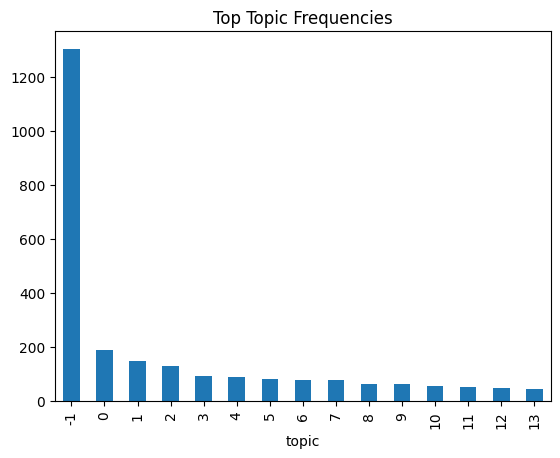

In [15]:
import matplotlib.pyplot as plt

df_chunks['topic'].value_counts().head(15).plot(kind='bar')
plt.title("Top Topic Frequencies")
plt.show()

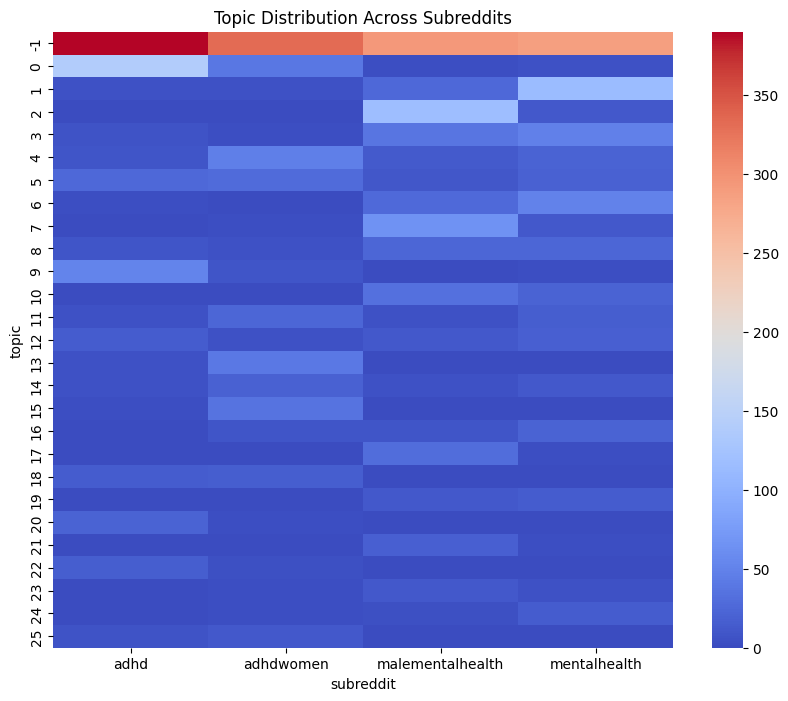

In [19]:
topic_sub = pd.crosstab(df_chunks['topic'], df_chunks['subreddit'])

import seaborn as sns
plt.figure(figsize=(10,8))
sns.heatmap(topic_sub, cmap="coolwarm")
plt.title("Topic Distribution Across Subreddits")
plt.show()

In [20]:
for topic in list(topic_entities.keys())[:5]:
    print(f"\nTopic {topic}:")
    print(topic_entities[topic])


Topic -1:
[('today', 113), ('second', 45), ('yesterday', 43), ('hour', 41), ('year', 38)]

Topic 25:
[('hour', 4), ('today', 3), ('weekend', 3), ('second', 2), ('week', 2)]

Topic 13:
[('today', 7), ('yesterday', 6), ('hour', 5), ('one', 3), ('australia', 3)]

Topic 4:
[('today', 4), ('month', 2), ('tomorrow', 2), ('october', 2), ('mess day week', 1)]

Topic 0:
[('today', 9), ('second', 5), ('year ago', 5), ('american', 5), ('english', 4)]


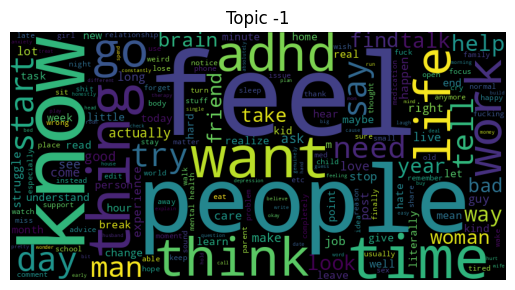

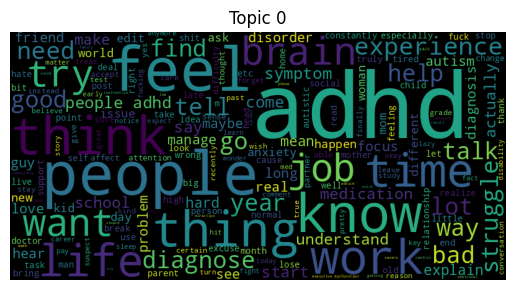

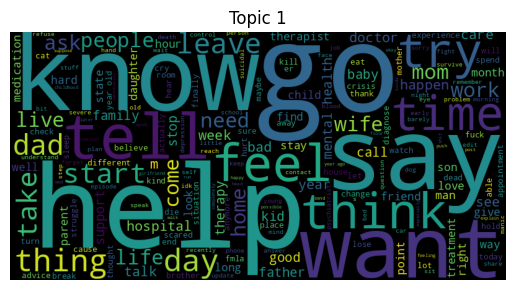

In [21]:
from wordcloud import WordCloud

for topic in df_chunks['topic'].value_counts().index[:3]:
    text = " ".join(df_chunks[df_chunks['topic']==topic]['text'])

    wc = WordCloud(width=800, height=400).generate(text)

    plt.imshow(wc)
    plt.axis("off")
    plt.title(f"Topic {topic}")
    plt.show()

In [22]:
for topic in df_chunks['topic'].value_counts().index[:3]:
    print(f"\n====== Topic {topic} Stories ======")

    samples = df_chunks[df_chunks['topic']==topic]['text'].sample(3)

    for s in samples:
        print("-", s[:300])


====== Topic -1 Stories ======
- got surprise diagnose autism night shift work treat context med student night work psychiatric emergency shift doctor uneventful night start pm entire evening doctor barely talk ask question unusual job level observe finally get break eat dinner thing get lighthearted doctor finally work feel free m
- dermatillomania skin picking adhd know adhd thing recently associate anxious type adhd finger absolute bloody mess right particularly stressful week work notice feel sting pain bleed little kid thing try work wear glove uncomfortable feel like weirdo bandaid end subconsciously pick fidget toy forget
- trigger mind overactive essentially put existential crisis distraction life busy boredom slippery slope fall reckless self destructive behavior handle lack stimulation edit additional thing absolutely dread have decision trust reliable cognitive functioning moment think decision

====== Topic 0 Stories ======
- stop call inattentive woman adhd see post parti

In [23]:
topic_model.visualize_heatmap()

In [24]:
nr_topics = 12  # you can try 10–15 depending on results

topic_model.reduce_topics(df_chunks['text'], nr_topics=nr_topics)

# Update topics
df_chunks['topic'] = topic_model.topics_

2026-04-19 23:19:45,935 - BERTopic - Topic reduction - Reducing number of topics
2026-04-19 23:19:46,004 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-19 23:19:48,595 - BERTopic - Representation - Completed ✓
2026-04-19 23:19:48,608 - BERTopic - Topic reduction - Reduced number of topics from 27 to 12


In [25]:
print(df_chunks['topic'].value_counts())

topic
-1     1303
 0      397
 1      304
 2      233
 3      155
 4      150
 5       89
 6       65
 7       51
 8       41
 9       40
 10      21
Name: count, dtype: int64


In [26]:
def generate_topic_labels(model):
    labels = {}

    for topic in model.get_topics().keys():
        if topic == -1:
            continue

        words = [word for word, _ in model.get_topic(topic)[:5]]

        label = " / ".join(words[:3])  # concise label
        labels[topic] = label

    return labels

topic_labels = generate_topic_labels(topic_model)

for t, label in topic_labels.items():
    print(f"Topic {t}: {label}")

Topic 0: live / job / leave
Topic 1: adhd / adderall / medication
Topic 2: man / woman / male
Topic 3: woman / man / date
Topic 4: sleep / brain / anxiety
Topic 5: accurate / truth / proud
Topic 6: clean / laundry / house
Topic 7: shower / hair / brush
Topic 8: video / instagram / rsd
Topic 9: house / eat / fridge
Topic 10: friend / talk / school


In [27]:
from collections import Counter

def enhance_labels_with_ner(df, topic_labels):
    final_labels = {}

    for topic in df['topic'].unique():
        if topic == -1:
            continue

        subset = df[df['topic'] == topic]['text']
        ents = []

        for text in subset:
            doc = nlp(text)
            ents.extend([ent.text.lower() for ent in doc.ents])

        common_ents = [e for e, _ in Counter(ents).most_common(3)]

        base_label = topic_labels.get(topic, "")

        final_labels[topic] = base_label + " | " + ", ".join(common_ents)

    return final_labels

final_topic_labels = enhance_labels_with_ner(df_chunks, topic_labels)

for t, label in final_topic_labels.items():
    print(f"\nTopic {t}: {label}")


Topic 6: clean / laundry / house | today, hour, yesterday

Topic 5: accurate / truth / proud | today, month, tomorrow

Topic 1: adhd / adderall / medication | today, month, fda

Topic 0: live / job / leave | today, year, week

Topic 10: friend / talk / school | year, today, year old

Topic 4: sleep / brain / anxiety | morning, second, daily

Topic 8: video / instagram / rsd | charlie kirk, minneapolis, hour

Topic 3: woman / man / date | year old, month, year

Topic 2: man / woman / male | iran, indian, today

Topic 9: house / eat / fridge | bee house, today, hour

Topic 7: shower / hair / brush | today, year, daily


In [28]:
df_chunks['topic_label'] = df_chunks['topic'].map(final_topic_labels)

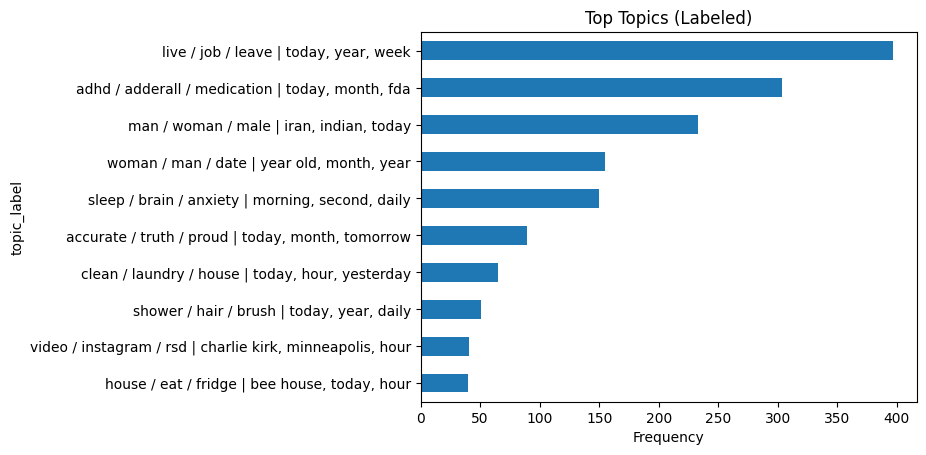

In [29]:
import matplotlib.pyplot as plt

topic_counts = df_chunks['topic_label'].value_counts().head(10)

topic_counts.plot(kind='barh')
plt.title("Top Topics (Labeled)")
plt.xlabel("Frequency")
plt.gca().invert_yaxis()
plt.show()

In [32]:
for topic in df_chunks['topic'].value_counts().index:
    if topic == -1: # Skip topic -1 as it's an outlier topic without a specific label
        continue
    # Only take the top 5 meaningful topics for display
    if list(df_chunks['topic'].value_counts().index).index(topic) >= 5:
        break

    print(f"\n====== {final_topic_labels[topic]} ======")

    samples = df_chunks[df_chunks['topic'] == topic]['text'].sample(3)

    for s in samples:
        print("-", s[:300])


====== live / job / leave | today, year, week ======
- check phone see miss call text wife say urgent dr come come try call answer run hospital opposite side room know expect enter pure chaos people cart lot blood turn like deer headlight say absolutely doctor look slight fear face like muster tell bad happen push wife hand lock like t rex arm body shak
- confused deeply hurt year feel like lifetime lose especially genuinely believe build real try process loss sense sudden rewriting history figure forward bitter lose faith long term love girlfriend year cheat married woman rewrote relationship abusive blame fallout affair struggle process betrayal lo
- mourn struggle life find meaning purpose value lose dog change drastically change well teach bring ride chapter feel like go raw fact realize make hard look work car recently break confidence dream find basic minimum living condition seemingly reach constantly think die live work build mean know wan

====== adhd / adderall / medication 

In [33]:
topic_summary = df_chunks.groupby(['topic', 'topic_label']).size().reset_index(name='count')
topic_summary = topic_summary.sort_values(by='count', ascending=False)

print(topic_summary)

    topic                                        topic_label  count
0       0             live / job / leave | today, year, week    397
1       1   adhd / adderall / medication | today, month, fda    304
2       2           man / woman / male | iran, indian, today    233
3       3         woman / man / date | year old, month, year    155
4       4   sleep / brain / anxiety | morning, second, daily    150
5       5  accurate / truth / proud | today, month, tomorrow     89
6       6   clean / laundry / house | today, hour, yesterday     65
7       7         shower / hair / brush | today, year, daily     51
8       8  video / instagram / rsd | charlie kirk, minnea...     41
9       9      house / eat / fridge | bee house, today, hour     40
10     10     friend / talk / school | year, today, year old     21
